In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io

# 设置论文级别的绘图风格
sns.set_theme(style="whitegrid", context="paper", font_scale=1.5)
plt.rcParams['font.family'] = 'serif'  # 使用衬线字体，更像学术论文
plt.rcParams['figure.figsize'] = (12, 6)

# === 1. 加载数据 ===
# 请将下面的文件名替换为你实际生成的 csv 文件名，例如 "benchmark_results_20260115.csv"
csv_file_path = "benchmark_result_time_analysis_20260119_152740.csv"
df = pd.read_csv(csv_file_path)


# -------------------------------------------------------------

# === 2. 关键步骤：定义排序逻辑 ===
# 我们必须按照规模从小到大排序，而不是字母顺序
target_order = [
    'nug12', 'had12', 
    'nug20', 'nug30', 'kra30a', 'tho30', 
    'tai40b', 'tai50b', 'tai60b', 'tai80b', 'tho150'
]

# 将 Instance 列转为 Categorical 类型，从而强制排序
df['Instance'] = pd.Categorical(df['Instance'], categories=target_order, ordered=True)
df = df.sort_values('Instance')

# === 3. 数据清洗 (处理 Inf) ===
max_valid_gap = df.replace(float('inf'), np.nan)['PGD_Gap'].max()
fill_value = min(100.0, max_valid_gap * 1.2 if not np.isnan(max_valid_gap) else 100.0)

df['PGD_Gap_Clean'] = df['PGD_Gap'].replace(float('inf'), fill_value)
df['SK_Gap_Clean'] = df['SK_Gap'].replace(float('inf'), fill_value)

print("Data loaded and sorted. Shape:", df.shape)
df.head()

Data loaded and sorted. Shape: (55, 22)


,Instance,Size,Seed,BKS,PGD_Obj,PGD_Gap,PGD_Time,PGD_Feasible,PGD_T_to_1%,PGD_T_to_2%,...,SK_Obj,SK_Gap,SK_Time,SK_Feasible,SK_T_to_1%,SK_T_to_2%,SK_T_to_5%,SK_T_to_10%,PGD_Gap_Clean,SK_Gap_Clean
0,nug12,12,0,578.0,746.0,29.065744,0.715943,True,NaN,NaN,...,586.0,1.384083,7.453491,True,NaN,2.063612,1.787116,1.372971,29.065744,1.384083
1,nug12,12,1,578.0,746.0,29.065744,0.353663,True,NaN,NaN,...,586.0,1.384083,6.933956,True,NaN,1.543546,1.253718,0.840317,29.065744,1.384083
2,nug12,12,2,578.0,746.0,29.065744,0.352515,True,NaN,NaN,...,586.0,1.384083,6.952983,True,NaN,1.535502,1.259571,0.835371,29.065744,1.384083
3,nug12,12,3,578.0,746.0,29.065744,0.354864,True,NaN,NaN,...,586.0,1.384083,6.966763,True,NaN,1.541112,1.265226,0.838441,29.065744,1.384083
4,nug12,12,4,578.0,746.0,29.065744,0.355172,True,NaN,NaN,...,586.0,1.384083,6.933085,True,NaN,1.556932,1.280986,0.855639,29.065744,1.384083


In [9]:
# 按 Instance 分组统计
summary = df.groupby('Instance', observed=False).agg({
    'Size': 'first',
    'PGD_Gap': ['mean', 'std', 'min'], # Min 展示 best case
    'SK_Gap': ['mean', 'std', 'min'],
    'PGD_Time': 'mean',
    'SK_Time': 'mean'
}).round(2)

# 重命名列以便阅读
summary.columns = [
    'N', 
    'PGD Gap(Avg)', 'PGD Gap(Std)', 'PGD Gap(Best)',
    'SK Gap(Avg)', 'SK Gap(Std)', 'SK Gap(Best)',
    'PGD Time(s)', 'SK Time(s)'
]

# 展示表格
display(summary)

# 导出为 CSV 方便后续做表
summary.to_csv("summary_table_for_latex.csv")
print("Summary table saved.")

,N,PGD Gap(Avg),PGD Gap(Std),PGD Gap(Best),SK Gap(Avg),SK Gap(Std),SK Gap(Best),PGD Time(s),SK Time(s)
Instance,,,,,,,,,
nug12,12,29.07,0.0,29.07,1.38,0.0,1.38,0.43,7.05
had12,12,17.92,0.0,17.92,0.61,0.0,0.61,0.36,6.95
nug20,20,27.94,0.0,27.94,0.16,0.0,0.16,0.75,8.82
nug30,30,32.36,0.0,32.36,2.22,0.0,2.22,1.07,14.35
kra30a,30,49.61,0.0,49.61,4.11,0.0,4.11,1.08,14.37
tho30,30,38.84,0.0,38.84,1.37,0.0,1.37,1.07,14.36
tai40b,40,61.95,0.0,61.95,12.72,0.0,12.72,2.00,30.36
tai50b,50,53.31,0.0,53.31,7.10,0.0,7.10,2.92,44.37
tai60b,60,32.31,0.0,32.31,4.64,0.0,4.64,3.19,44.45


Summary table saved.


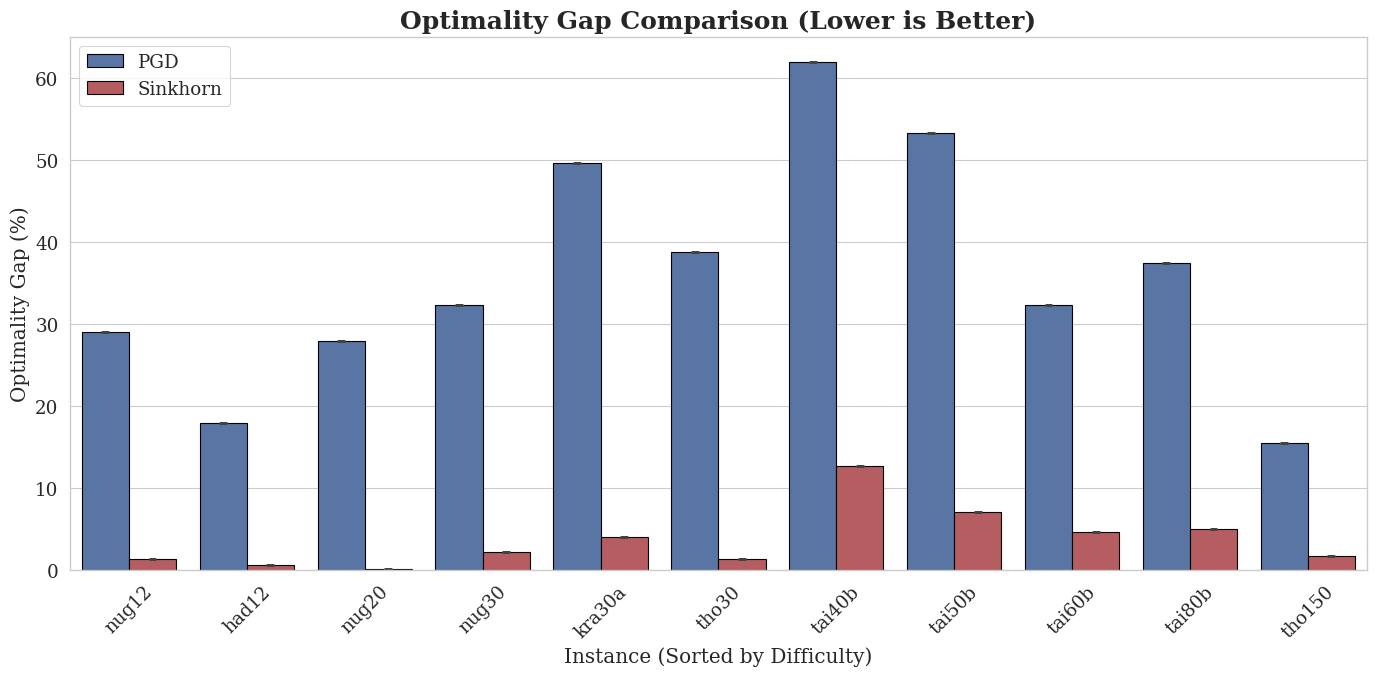

In [10]:
# 1. 数据变形 (Wide to Long) 以适配 Seaborn
df_long = pd.melt(df, 
                  id_vars=['Instance', 'Size'], 
                  value_vars=['PGD_Gap_Clean', 'SK_Gap_Clean'],
                  var_name='Method', 
                  value_name='Gap (%)')

# 重命名 Method 标签
df_long['Method'] = df_long['Method'].map({
    'PGD_Gap_Clean': 'PGD', 
    'SK_Gap_Clean': 'Sinkhorn'   
})

# 2. 画图
plt.figure(figsize=(14, 7))
ax = sns.barplot(data=df_long, x='Instance', y='Gap (%)', hue='Method', 
                 palette=['#4c72b0', '#c44e52'], # 蓝红经典配色
                 edgecolor='black', capsize=0.1, errorbar='sd') # sd 表示标准差

# 3. 细节美化
plt.title('Optimality Gap Comparison (Lower is Better)', fontsize=18, fontweight='bold')
plt.ylabel('Optimality Gap (%)')
plt.xlabel('Instance (Sorted by Difficulty)')
plt.legend(title=None, loc='upper left', frameon=True)
plt.xticks(rotation=45)

# 如果有截断数据，可以在这里画一条虚线表示 "Did not converge"
# plt.axhline(y=100, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('fig1_gap_comparison.png', dpi=300) # 保存为矢量图
plt.show()

/tmp/ipykernel_366706/1495510778.py:9: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:black'` for the same effect.

  sns.stripplot(data=df_long, x='Instance', y='Gap (%)', hue='Method',


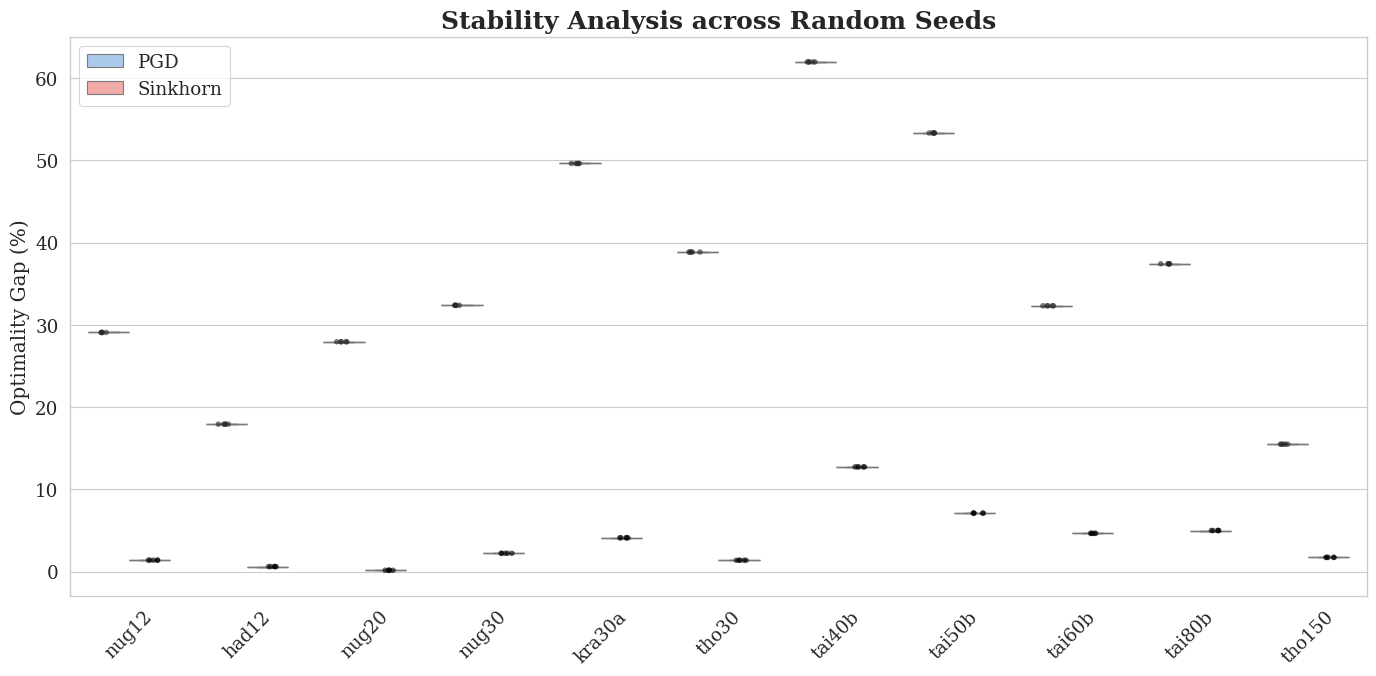

In [11]:
plt.figure(figsize=(14, 7))

# Boxplot
sns.boxplot(data=df_long, x='Instance', y='Gap (%)', hue='Method',
            palette=['#a1c9f4', '#ff9f9b'], # 浅色填充
            width=0.7, showfliers=False) # 不显示极端异常值以免压缩主图

# 叠加 Swarmplot (散点)，让审稿人看到这 5 个点具体在哪
sns.stripplot(data=df_long, x='Instance', y='Gap (%)', hue='Method',
              dodge=True, color='black', alpha=0.6, size=4, legend=False)

plt.title('Stability Analysis across Random Seeds', fontsize=18, fontweight='bold')
plt.ylabel('Optimality Gap (%)')
plt.xlabel('')
plt.xticks(rotation=45)
plt.legend(loc='upper left')

plt.tight_layout()
plt.savefig('fig2_stability.png', dpi=300)
plt.show()

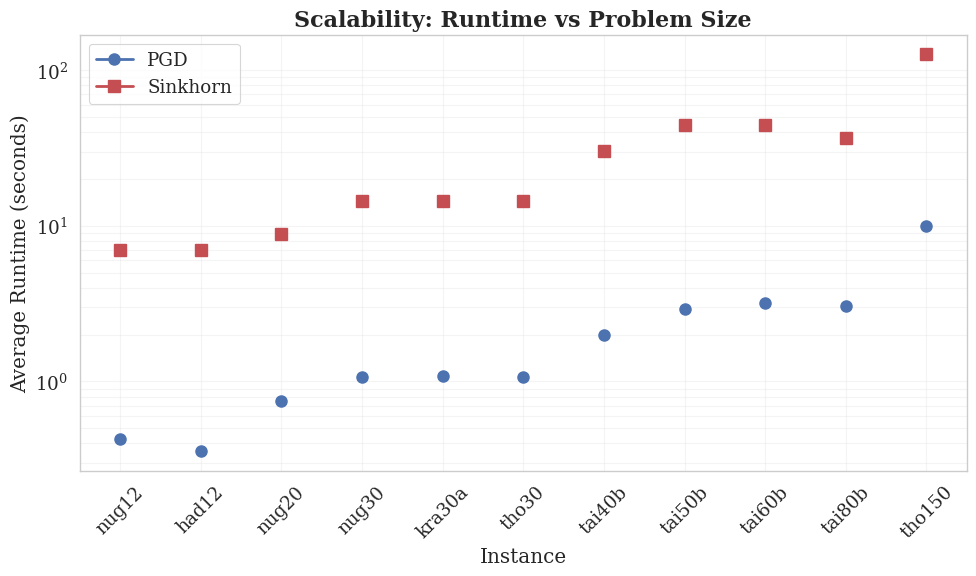

In [12]:
# 计算每个 Instance 的平均时间
time_df = df.groupby(['Instance', 'Size'], observed=False)[['PGD_Time', 'SK_Time']].mean().reset_index()

plt.figure(figsize=(10, 6))

# 画 PGD 曲线
plt.plot(time_df['Instance'], time_df['PGD_Time'], 
         marker='o', label='PGD', color='#4c72b0', linewidth=2, markersize=8)

# 画 Ours 曲线
plt.plot(time_df['Instance'], time_df['SK_Time'], 
         marker='s', label='Sinkhorn', color='#c44e52', linewidth=2, markersize=8)

plt.title('Scalability: Runtime vs Problem Size', fontsize=16, fontweight='bold')
plt.ylabel('Average Runtime (seconds)')
plt.xlabel('Instance')
plt.xticks(rotation=45)

# 关键：通常时间跨度很大，建议用对数坐标
plt.yscale('log') 
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend()

plt.tight_layout()
plt.savefig('fig3_scalability.png', dpi=300)
plt.show()

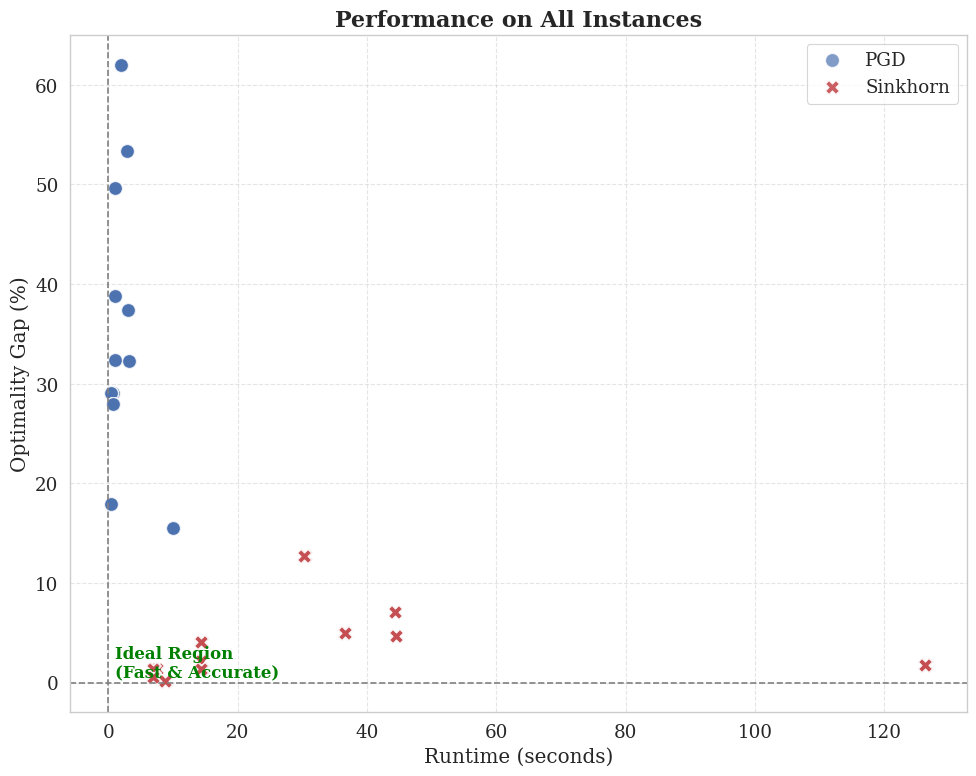

No hard instances data available yet to plot Figure 4.


In [14]:
# # 过滤出 Hard Instances
# hard_instances = ['tai40b', 'tai50b', 'tai60b', 'tai80b', 'tho150']
# # 如果你的数据里还没有这些，代码会画空图，不报错
# df_hard = df[df['Instance'].isin(hard_instances)].copy()

# if not df_hard.empty:
plt.figure(figsize=(10, 8))

# 绘制 PGD 的点
sns.scatterplot(data=df, x='PGD_Time', y='PGD_Gap_Clean', 
                label='PGD', color='#4c72b0', s=100, marker='o', alpha=0.7)

# 绘制 Ours 的点
sns.scatterplot(data=df, x='SK_Time', y='SK_Gap_Clean', 
                label='Sinkhorn', color='#c44e52', s=100, marker='X', alpha=0.9)

# 标注每个点属于哪个 Instance (可选，如果点太多就不要标)
# for i in range(df.shape[0]):
#     plt.text(df.iloc[i]['SK_TotalTime'], df.iloc[i]['SK_Gap_Clean'], 
#                 df.iloc[i]['Instance'], fontsize=9, alpha=0.5)

plt.title('Performance on All Instances', fontsize=16, fontweight='bold')
plt.xlabel('Runtime (seconds)')
plt.ylabel('Optimality Gap (%)')

# 理想区域：左下角
plt.axvline(x=0, color='gray', linestyle='--')
plt.axhline(y=0, color='gray', linestyle='--')
plt.text(0.05, 0.05, 'Ideal Region\n(Fast & Accurate)', transform=plt.gca().transAxes, 
            fontsize=12, color='green', fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig('fig4_instances.png', dpi=300)
plt.show()
# else:
print("No hard instances data available yet to plot Figure 4.")